# Lesson 1: ML Fundamentals

## What is Machine Learning?

Machine Learning is a field where computers learn patterns from data without being explicitly programmed for every scenario.

- **Traditional programming:** Rules + Data → Answers
- **Machine Learning:** Data + Answers → Rules

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import load_diabetes

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Features, Labels, Training, Prediction

In [2]:
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Feature matrix shape: {X.shape}")
print(f"Feature names: {list(X.columns)}")
print(f"Target range: {y.min():.1f} - {y.max():.1f}")
X.head()

Feature matrix shape: (442, 10)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: 25.0 - 346.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 353
Test samples: 89


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Train R²: {r2_score(y_train, y_train_pred):.3f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred):.3f}")
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.1f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_test_pred):.1f}")

Train R²: 0.528
Test R²:  0.453
Train MSE: 2868.5
Test MSE:  2900.2


## 2. Overfitting, Underfitting, and the Bias-Variance Tradeoff

We create a synthetic dataset to visualize these concepts.

Degree 1: Train MSE = 0.2505, Test MSE = 0.2673
Degree 4: Train MSE = 0.0249, Test MSE = 0.0333
Degree 15: Train MSE = 0.0148, Test MSE = 0.2219


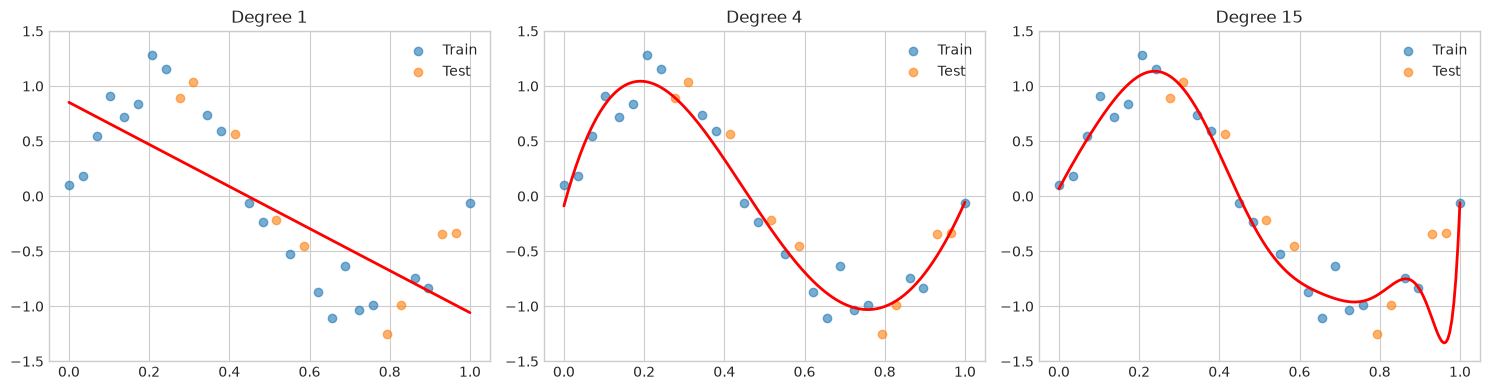

In [5]:
X_sin = np.linspace(0, 1, 30).reshape(-1, 1)
y_sin = np.sin(2 * np.pi * X_sin.ravel()) + np.random.normal(0, 0.2, 30)

X_sin_train, X_sin_test, y_sin_train, y_sin_test = train_test_split(
    X_sin, y_sin, test_size=0.3, random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [1, 4, 15]

for i, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg)
    Xp_train = poly.fit_transform(X_sin_train)
    Xp_test = poly.transform(X_sin_test)

    m = LinearRegression()
    m.fit(Xp_train, y_sin_train)

    X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
    y_plot = m.predict(poly.transform(X_plot))

    axes[i].scatter(X_sin_train, y_sin_train, label='Train', alpha=0.6)
    axes[i].scatter(X_sin_test, y_sin_test, label='Test', alpha=0.6)
    axes[i].plot(X_plot, y_plot, 'r-', linewidth=2)
    axes[i].set_title(f'Degree {deg}')
    axes[i].set_ylim(-1.5, 1.5)
    axes[i].legend()

    tr_mse = mean_squared_error(y_sin_train, m.predict(Xp_train))
    te_mse = mean_squared_error(y_sin_test, m.predict(Xp_test))
    print(f"Degree {deg}: Train MSE = {tr_mse:.4f}, Test MSE = {te_mse:.4f}")

plt.tight_layout()
plt.show()

**Discussion:** Degree 1 underfits (high bias), Degree 4 fits well, Degree 15 overfits (high variance).

## 3. Biotechnology Example: Gene Expression → Drug Response

In [6]:
from sklearn.datasets import make_classification

X_gene, y_response = make_classification(
    n_samples=200, n_features=5, n_informative=3,
    n_redundant=1, random_state=42
)

gene_names = [f'GENE_{i}' for i in range(X_gene.shape[1])]
gene_df = pd.DataFrame(X_gene, columns=gene_names)
gene_df['responder'] = y_response

print(f"Responders: {y_response.sum()} / {len(y_response)}")
gene_df.head()

Responders: 99 / 200


,GENE_0,GENE_1,GENE_2,GENE_3,GENE_4,responder
0,0.185234,0.151736,-1.280148,0.113477,1.315767,1
1,1.471465,-0.088970,-0.709765,-1.509683,-1.557952,0
2,-2.010294,-1.848118,-1.280667,2.169183,-0.157214,0
3,1.422282,-1.327818,-1.475146,-1.534802,-1.753574,0
4,-0.904773,-0.773601,-0.908675,1.063587,-0.683432,1


## 4. SaaS Example: Churn Prediction Features

In [7]:
n_users = 1000
np.random.seed(42)

churn_data = pd.DataFrame({
    'login_frequency': np.random.randint(0, 50, n_users),
    'support_tickets': np.random.poisson(1, n_users),
    'days_since_last_login': np.random.randint(0, 60, n_users),
    'age_of_account_months': np.random.randint(1, 48, n_users),
})

# Simulate churn: users inactive for >30 days with high tickets are likely to churn
churn_prob = 1 / (1 + np.exp(-(
    -3 + 0.05 * churn_data['days_since_last_login']
    + 0.3 * churn_data['support_tickets']
    - 0.02 * churn_data['age_of_account_months']
)))
churn_data['churned'] = (np.random.random(n_users) < churn_prob).astype(int)

print(f"Churn rate: {churn_data['churned'].mean():.1%}")
churn_data.head()

Churn rate: 20.4%


,login_frequency,support_tickets,days_since_last_login,age_of_account_months,churned
0,38,1,54,14,1
1,28,0,27,10,0
2,14,0,15,47,0
3,42,2,46,36,0
4,7,1,16,34,0


## 5. Exercises

### Level 1 — Basic
Explain in your own words the difference between traditional programming and Machine Learning.

### Level 2 — Implementation
Train a `LinearRegression` on `churn_data` (features: login_frequency, support_tickets, days_since_last_login; target: churned). Report train and test accuracy.

### Level 3 — Critical Thinking
Your model has train R² = 0.98 and test R² = 0.32. What is happening? What would you do?

In [8]:
# Your code for Level 2 here

## 6. Coding Challenge

Write `diagnose_fit(model, X_train, X_test, y_train, y_test)` that:
1. Computes train and test scores
2. Returns 'overfitting', 'underfitting', or 'good' based on thresholds
3. Prints the diagnosis

In [9]:
def diagnose_fit(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    if train_score < 0.5:
        diagnosis = 'underfitting'
    elif train_score - test_score > 0.15:
        diagnosis = 'overfitting'
    else:
        diagnosis = 'good'

    print(f"Train score: {train_score:.3f}, Test score: {test_score:.3f}")
    print(f"Diagnosis: {diagnosis}")
    return diagnosis


model = LinearRegression()
diagnose_fit(model, X_train, X_test, y_train, y_test)

Train score: 0.528, Test score: 0.453
Diagnosis: good


'good'

## Summary

- Features (X) are inputs, labels (y) are outputs
- Training fits the model; prediction applies it
- Generalization = performance on unseen data
- Overfitting: high train score, low test score
- Underfitting: low train and test scores
- Bias-variance tradeoff: balance simplicity and flexibility
- Always use train/test split for honest evaluation